In [321]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
from thefuzz import process, fuzz
%autosave 60

Autosaving every 60 seconds


In [69]:
df = pd.read_csv("../../datasets/processed/mergedDF.csv")

In [71]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [318]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35104 entries, 0 to 35103
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   appid      35104 non-null  int64  
 1   name       35104 non-null  str    
 2   min_req    35103 non-null  str    
 3   rec_req    21324 non-null  str    
 4   min_cpu    32523 non-null  str    
 5   cpu_bench  32522 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 18.7 MB


In [72]:
df.head()

,appid,name,min_req,rec_req
0,379720,DOOM,"Minimum:,OS:,Windows 7/8.1/10 (64-bit versions...","Recommended:,OS:,Windows 7/8.1/10 (64-bit vers..."
1,578080,PLAYERUNKNOWN'S BATTLEGROUNDS,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o..."
2,637090,BATTLETECH,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o..."
3,221100,DayZ,"Minimum:,OS:,Windows 7/8.1 64-bit,Processor:,I...","Recommended:,OS:,Windows 10 64-bit,Processor:,..."
4,8500,EVE Online,"Minimum:,OS:,Windows 7,Processor:,Intel Dual C...","Recommended:,OS:,Windows 10,Processor:,Intel i..."


In [73]:
def extract_cpu(text):
    """Extract CPU info from Processor line."""
    CPU_LINE_PATTERN = r'(?i)(?:Processor|CPU):[,\s]+([^,]+)'
    if pd.isna(text):
        return None
    text = str(text)
    match = re.search(CPU_LINE_PATTERN, text)
    if match:
        return match.group(1).strip()
    return None

In [74]:
def extract_gpu(text):
    text = str(text)
    text = text.split(',')
    for i in text:
        if "Graphics" in i:
            return text[text.index(i)+1]
    return None
def extract_gpu2(text):
    gpu = re.search(r"(?:Graphics(?: Card)?|GPU)\s*[:|,]+\s*(?P<gpu_name>.*?)(?P<vram>\d+\s?(?:GB|MB)(?:\s?VRAM|Memory|Ram)?)?(?=\s*(?:,|DirectX|Storage|Additional|Network|OS|Minimum|$))", text)
    if gpu:
        return gpu.group()
    return None

In [75]:
df['min_cpu'] = df['min_req'].apply(lambda x: extract_cpu(x))

---

In [76]:
benchdf = pd.read_csv("../../datasets/raw/CPU_UserBenchmarks.csv")

In [77]:
df.head()

,appid,name,min_req,rec_req,min_cpu
0,379720,DOOM,"Minimum:,OS:,Windows 7/8.1/10 (64-bit versions...","Recommended:,OS:,Windows 7/8.1/10 (64-bit vers...",Intel Core i5-2400/AMD FX-8320 or better
1,578080,PLAYERUNKNOWN'S BATTLEGROUNDS,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",Intel Core i5-4430 / AMD FX-6300
2,637090,BATTLETECH,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",Intel® Core™ i3-2105 or AMD® Phenom™ II X3 720
3,221100,DayZ,"Minimum:,OS:,Windows 7/8.1 64-bit,Processor:,I...","Recommended:,OS:,Windows 10 64-bit,Processor:,...",Intel Core i5-4430
4,8500,EVE Online,"Minimum:,OS:,Windows 7,Processor:,Intel Dual C...","Recommended:,OS:,Windows 10,Processor:,Intel i...",Intel Dual Core @ 2.0 GHz


In [78]:
benchdf.head()

,Type,Part Number,Brand,Model,Rank,Benchmark,Samples,URL
0,CPU,BX8071514900KS,Intel,Core i9-14900KS,1,133.0,1592,https://cpu.userbenchmark.com/SpeedTest/229530...
1,CPU,BX8071514900KF,Intel,Core i9-14900KF,2,131.0,7773,https://cpu.userbenchmark.com/SpeedTest/221221...
2,CPU,BX8071514900K,Intel,Core i9-14900K,3,131.0,19876,https://cpu.userbenchmark.com/Intel-Core-i9-14...
3,CPU,BX8071513900KS,Intel,Core i9-13900KS,4,131.0,4204,https://cpu.userbenchmark.com/SpeedTest/200081...
4,CPU,BX8071514700KF,Intel,Core i7-14700KF,5,130.0,4842,https://cpu.userbenchmark.com/SpeedTest/221202...


In [79]:
df['min_cpu'].values

<ArrowStringArray>
[                                                                  'Intel Core i5-2400/AMD FX-8320 or better',
                                                                           'Intel Core i5-4430 / AMD FX-6300',
                                                             'Intel® Core™ i3-2105 or AMD® Phenom™ II X3 720',
                                                                                         'Intel Core i5-4430',
                                                                                  'Intel Dual Core @ 2.0 GHz',
                                                                                       'Intel® Core™ i5-4460',
 'Intel Core2 Duo E6750 (2 * 2660) or equivalent | AMD Athlon 64 X2 Dual Core 6000+ (2 * 3000) or equivalent',
                                                                                                      'INTEL',
                                                                        'Intel® Core i3 or AM

In [80]:
cpu_bench = dict(zip(benchdf['Model'], benchdf['Benchmark']))

In [81]:
def clean_cpu_string(text):
    if pd.isna(text):
        return
    # 1. Remove símbolos de marca registrada e caracteres especiais
    text = re.sub(r'[®™©@]', '', text)
    # 2. Remove ruídos comuns que confundem o fuzzy match
    noise = [
        'or better', 'or equivalent', 'or higher processor', 
        'equivalent', 'processor', 'generation', '3rd', '4th'
    ]
    for word in noise:
        text = re.compile(re.escape(word), re.IGNORECASE).sub('', text)
    
    # 3. Remove especificações de núcleos/clock entre parênteses ex: (2 * 2660)
    text = re.sub(r'\(.*?\)', '', text)
    
    return text.strip()

In [82]:
df['min_cpu'] = df['min_cpu'].apply(lambda x: clean_cpu_string(x))

In [83]:
df['min_cpu']

0                           Intel Core i5-2400/AMD FX-8320
1                         Intel Core i5-4430 / AMD FX-6300
2               Intel Core i3-2105 or AMD Phenom II X3 720
3                                       Intel Core i5-4430
4                                 Intel Dual Core  2.0 GHz
                               ...                        
35099    2.66 GHz Intel Core2 Duo E6750 or 2.8 GHz AMD ...
35100    2.66 GHz Intel Core2 Duo E6750 or 2.8 GHz AMD ...
35101                                              1.6 GHz
35102                      Intel Core i3 550 3.2GHz or AMD
35103                                              1.6 GHz
Name: min_cpu, Length: 35104, dtype: str

In [84]:
def get_minimum_cpu_score(cpu_string, threshold=70):
    if not cpu_string or pd.isna(cpu_string):
        return None
    
    # Quebra a string por separadores comuns na Steam (|, /, 'or', ',')
    # Ex: "Intel Core i5-3470 | AMD FX-6300" -> ["Intel Core i5-3470", "AMD FX-6300"]
    cpu_candidates = re.split(r'\s*(?:\||/|or|,)\s*', cpu_string, flags=re.IGNORECASE)
    
    found_scores = []
    
    for candidate in cpu_candidates:
        # Busca o melhor match para cada candidato no dicionário
        match, score = process.extractOne(
            candidate, 
            cpu_bench.keys(), 
            scorer=fuzz.token_set_ratio
        )
        
        if score >= threshold:
            found_scores.append(cpu_bench[match])
    
    # Se encontrou scores, retorna o menor (mínimo exigido)
    # Se não encontrou nada, retorna None
    return min(found_scores) if found_scores else min(cpu_bench.values())

In [ ]:
df['cpu_bench'] = df['min_cpu'].apply(lambda x: get_minimum_cpu_score(x))

In [87]:
df.isna().sum()

appid            0
name             0
min_req          1
rec_req      13780
min_cpu       2581
cpu_bench     2582
dtype: int64

In [337]:
df.loc[df['cpu_bench'] > 120, ['min_req', 'min_cpu', 'cpu_bench']] # TODO: fix mistaken cpubench matching

,min_req,min_cpu,cpu_bench
709,"Minimum: , OS *: Windows 8 / 8.1 / 10, Process...",Intel Core i5 / i7,130.0
740,"Minimum:,OS:,Windows,Processor:,i5 or equivale...",i5,124.0
824,"Minimum:,OS:,Windows 10,Processor:,i5,Memory:,...",i5,124.0
873,"Minimum:,Requires a 64-bit processor and opera...",Intel i5/i7,130.0
902,"Minimum: , OS *: Windows 7 / 8 / 8.1, Processo...",Intel Core i5 / i7,130.0
...,...,...,...
34297,"Minimum:,OS:,64,Processor:,i5 or faster,Memory...",i5 or faster,124.0
34418,"Minimum: , OS *: Windows 7 / 8 / 8.1 / 10, Pro...",Intel i5 or i7,130.0
34457,"Minimum:,Requires a 64-bit processor and opera...",i5,124.0
34885,"Minimum:,Requires a 64-bit processor and opera...",i5,124.0


In [322]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples

In [215]:
feature = df[['cpu_bench']].dropna()

In [276]:
#X = StandardScaler().fit_transform(feature)
X = feature

In [311]:
X = X[(X['cpu_bench'] > 30) & (X['cpu_bench'] < 92)]
X

,cpu_bench
0,58.5
1,55.2
2,48.1
3,65.2
5,62.1
...,...
35094,41.0
35098,37.8
35099,37.8
35100,37.8


In [312]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto", init='k-means++').fit(X)

In [313]:
labels = kmeans.predict(X)
labels

array([0, 0, 2, ..., 1, 1, 2], shape=(11567,), dtype=int32)

In [314]:
centers = kmeans.cluster_centers_

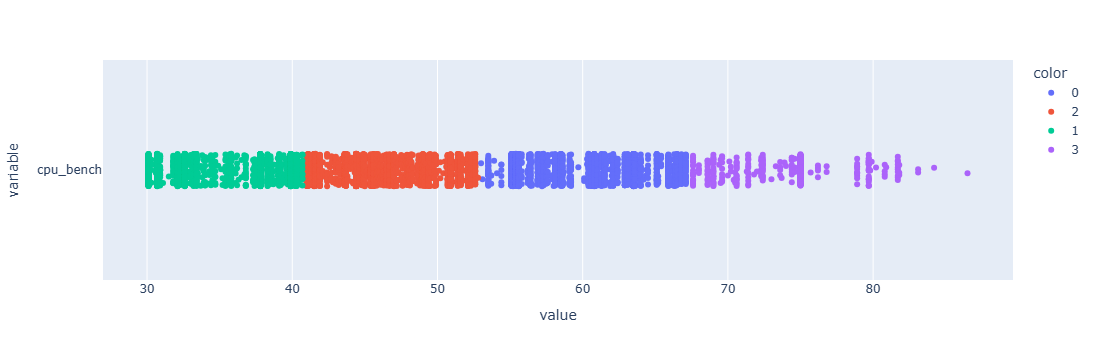

In [316]:
px.strip(X, color=labels, orientation='h', stripmode='overlay')

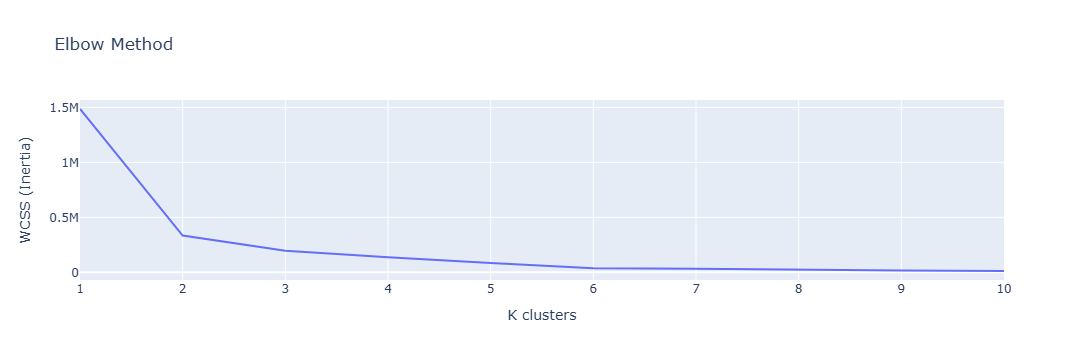

In [320]:
# Elbow Method
# Lista para armazenar os valores de inércia (WCSS)
wcss = []

# Testamos o K de 1 a 10
for i in range(1, 11):
    # n_init="auto" é o padrão para evitar avisos em versões novas
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init="auto")
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotando o gráfico
pltdf = pd.DataFrame({'K clusters': range(1,11), 'WCSS (Inertia)': wcss})
px.line(pltdf, x='K clusters', y='WCSS (Inertia)', title='Elbow Method')

In [344]:
score_medio = silhouette_score(X, labels)
score_medio

0.5713553981159373